##### wgi_cc   # Control of Corruption
##### wgi_ge   # Government Effectiveness
##### wgi_pv   # Political Stability
##### wgi_rl   # Rule of Law
##### wgi_rq   # Regulatory Quality
#####wgi_va   # Voice and Accountability

In [1]:
!pip install -q scikit-learn xgboost shap
!pip install -q tqdm

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm



In [76]:
projectDf = pd.read_excel('/content/IEG_ICRR_PPAR_Ratings_2025-09-03.xlsx')
riskDf = pd.read_csv('/content/CRC_Yearly_Final_1999_2025.csv')
wgi = pd.read_csv("WB_WGI_r.csv")

In [80]:
projectDf.head()

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Region,Country,Country FCS Status,Country Lending Group,Agreement Type,Lending Instrument,Project Volume,TXT,PDF,Lesson
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,East Asia and Pacific,Thailand,0.0,IBRD,MONT,IPF,>=25 million & <50 million,http://documents.worldbank.org/curated/en/9472...,http://documents.worldbank.org/curated/en/9472...,The ICR (pp. 25-26) identified 6 lessons learn...
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,Latin America and Caribbean,Argentina,0.0,IBRD,MONT,IPF,>=10 million & <25 million,http://documents.worldbank.org/curated/en/1106...,http://documents.worldbank.org/curated/en/1106...,The ICR (pages 17-18) provides the following u...
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Latin America and Caribbean,Argentina,0.0,IBRD,IBRD,IPF,>=50 million & <100 million,http://documents.worldbank.org/curated/en/7836...,http://documents.worldbank.org/curated/en/7836...,The ICR provides the following key lessons:Imp...
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,Latin America and Caribbean,Brazil,0.0,IBRD,IBRD,IPF,>=100 million,http://documents.worldbank.org/curated/en/5835...,http://documents.worldbank.org/curated/en/5835...,The ICR (pp. 31-32) presented several useful l...
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Europe and Central Asia,Uzbekistan,0.0,BLEND,IBRD,IPF,>=50 million & <100 million,http://documents.worldbank.org/curated/en/2214...,http://documents.worldbank.org/curated/en/2214...,The ICR offers a number of lessons of which th...


In [81]:
projectDf = projectDf.drop(columns=['TXT','PDF','Lesson'])
projectDf

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,IEG Monitoring and Evaluation Quality Ratings,Global Practice,Practice Group,Region,Country,Country FCS Status,Country Lending Group,Agreement Type,Lending Instrument,Project Volume
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,Substantial,"Environment, Natural Resources & the Blue Economy",SD,East Asia and Pacific,Thailand,0.0,IBRD,MONT,IPF,>=25 million & <50 million
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,Substantial,"Environment, Natural Resources & the Blue Economy",SD,Latin America and Caribbean,Argentina,0.0,IBRD,MONT,IPF,>=10 million & <25 million
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Modest,Energy & Extractives,INFRA,Latin America and Caribbean,Argentina,0.0,IBRD,IBRD,IPF,>=50 million & <100 million
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,Modest,Water,SD,Latin America and Caribbean,Brazil,0.0,IBRD,IBRD,IPF,>=100 million
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Modest,Water,SD,Europe and Central Asia,Uzbekistan,0.0,BLEND,IBRD,IPF,>=50 million & <100 million
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10741,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10742,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10743,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10744,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
riskDf.head()

,Country,Year,CRC_Risk
0,Afghanistan,1999,7.0
1,Afghanistan,2000,NaN
2,Afghanistan,2001,NaN
3,Afghanistan,2002,NaN
4,Afghanistan,2003,NaN


In [83]:
projectDf_r = projectDf.merge(
    riskDf[["Country", "Year", "CRC_Risk"]],
    left_on=["Country", "Approval FY"],
    right_on=["Country", "Year"],
    how="left"
)


projectDf_r.head()

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Practice Group,Region,Country,Country FCS Status,Country Lending Group,Agreement Type,Lending Instrument,Project Volume,Year,CRC_Risk
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,SD,East Asia and Pacific,Thailand,0.0,IBRD,MONT,IPF,>=25 million & <50 million,NaN,NaN
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,SD,Latin America and Caribbean,Argentina,0.0,IBRD,MONT,IPF,>=10 million & <25 million,NaN,NaN
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,INFRA,Latin America and Caribbean,Argentina,0.0,IBRD,IBRD,IPF,>=50 million & <100 million,1999.0,5.0
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,SD,Latin America and Caribbean,Brazil,0.0,IBRD,IBRD,IPF,>=100 million,2010.0,3.0
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,SD,Europe and Central Asia,Uzbekistan,0.0,BLEND,IBRD,IPF,>=50 million & <100 million,2003.0,7.0


In [84]:
rating_map = {
    "Highly Unsatisfactory": 0,
    "Unsatisfactory": 1,
    "Moderately Unsatisfactory": 2,
    "Moderately Satisfactory": 3,
    "Satisfactory": 4,
    "Highly Satisfactory": 5
}
projectDf_r["Outcome_Score"] = projectDf_r["IEG Outcome Ratings"].map(rating_map)
projectDf_r

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Region,Country,Country FCS Status,Country Lending Group,Agreement Type,Lending Instrument,Project Volume,Year,CRC_Risk,Outcome_Score
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,East Asia and Pacific,Thailand,0.0,IBRD,MONT,IPF,>=25 million & <50 million,NaN,NaN,4.0
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,Latin America and Caribbean,Argentina,0.0,IBRD,MONT,IPF,>=10 million & <25 million,NaN,NaN,3.0
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Latin America and Caribbean,Argentina,0.0,IBRD,IBRD,IPF,>=50 million & <100 million,1999.0,5.0,2.0
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,Latin America and Caribbean,Brazil,0.0,IBRD,IBRD,IPF,>=100 million,2010.0,3.0,1.0
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Europe and Central Asia,Uzbekistan,0.0,BLEND,IBRD,IPF,>=50 million & <100 million,2003.0,7.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10741,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10742,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10743,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10744,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
projectDf_r["sector"] = (
    projectDf_r["Global Practice"]
    .astype(str)
    .apply(lambda x: x.split(",")[0].strip() if isinstance(x, str) else None)
)

projectDf_r["sector"].value_counts().head(10)

,count
sector,
Macroeconomics,1269
Urban,1252
Transport,988
Education,942
Energy & Extractives,896
Water,817
Finance,802
Environment,790
Agriculture and Food,749


In [77]:
# (1) Estimate 항목만 필터
wgi_est = wgi[wgi["INDICATOR_LABEL"].str.endswith("Estimate")].copy()

# (2) 필요한 컬럼만 추출
wgi_est = wgi_est[["REF_AREA", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]]

# (3) 가로 피벗
wgi_wide = (
    wgi_est.pivot_table(
        index=["REF_AREA", "TIME_PERIOD"],
        columns="INDICATOR_LABEL",
        values="OBS_VALUE"
    )
    .reset_index()
)

# (4) 컬럼명 간결하게 정리
rename_map = {
    "Control of Corruption: Estimate": "wgi_cc",
    "Government Effectiveness: Estimate": "wgi_ge",
    "Political Stability and Absence of Violence/Terrorism: Estimate": "wgi_pv",
    "Rule of Law: Estimate": "wgi_rl",
    "Regulatory Quality: Estimate": "wgi_rq",
    "Voice and Accountability: Estimate": "wgi_va"
}
wgi_wide = wgi_wide.rename(columns=rename_map)
wgi_wide = wgi_wide.rename(columns={"REF_AREA": "iso3c", "TIME_PERIOD": "year"})

# (5) 정리 및 확인
wgi_clean = wgi_wide[["iso3c","year","wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]].drop_duplicates()
print("Cleaned WGI shape:", wgi_clean.shape)
wgi_clean.head()

Cleaned WGI shape: (5246, 8)


INDICATOR_LABEL,iso3c,year,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va
0,ABW,2004,1.165965,1.281389,0.993218,0.915527,0.762954,0.737521
1,ABW,2005,1.269663,1.287598,1.376416,0.847438,0.864074,1.153230
2,ABW,2006,1.251313,1.279818,1.303461,0.810431,0.855287,1.017273
3,ABW,2007,1.261871,1.246601,1.286569,0.826464,0.877206,0.972129
4,ABW,2008,1.276775,1.270925,1.316396,0.847226,0.894702,0.967198


In [78]:
wgi_est = wgi[wgi["INDICATOR_LABEL"].str.endswith("Estimate")].copy()
wgi_est = wgi_est[["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]]

wgi_wide = (
    wgi_est.pivot_table(
        index=["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD"],
        columns="INDICATOR_LABEL",
        values="OBS_VALUE"
    )
    .reset_index()
)

rename_map = {
    "Control of Corruption: Estimate": "wgi_cc",
    "Government Effectiveness: Estimate": "wgi_ge",
    "Political Stability and Absence of Violence/Terrorism: Estimate": "wgi_pv",
    "Rule of Law: Estimate": "wgi_rl",
    "Regulatory Quality: Estimate": "wgi_rq",
    "Voice and Accountability: Estimate": "wgi_va"
}

wgi_clean = (
    wgi_wide.rename(columns=rename_map)
    .rename(columns={"REF_AREA": "iso3c", "REF_AREA_LABEL": "Country", "TIME_PERIOD": "year"})
    [["iso3c","Country","year","wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]]
)

In [79]:
wgi_clean.head()

INDICATOR_LABEL,iso3c,Country,year,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va
0,ABW,Aruba,2004,1.165965,1.281389,0.993218,0.915527,0.762954,0.737521
1,ABW,Aruba,2005,1.269663,1.287598,1.376416,0.847438,0.864074,1.153230
2,ABW,Aruba,2006,1.251313,1.279818,1.303461,0.810431,0.855287,1.017273
3,ABW,Aruba,2007,1.261871,1.246601,1.286569,0.826464,0.877206,0.972129
4,ABW,Aruba,2008,1.276775,1.270925,1.316396,0.847226,0.894702,0.967198


In [86]:
import pandas as pd
import numpy as np

# ======================================
# 0) 복사 및 기본 클린업
# ======================================
proj = projectDf_r.copy()
wgi_use = wgi_clean.copy()

proj = proj[proj["Country"].notna()]
proj["Country"] = proj["Country"].astype(str).str.strip()
proj["Approval FY"] = pd.to_numeric(proj["Approval FY"], errors="coerce")
proj = proj.dropna(subset=["Approval FY"])

wgi_use["Country"] = wgi_use["Country"].astype(str).str.strip()
wgi_use["year"] = pd.to_numeric(wgi_use["year"], errors="coerce")
wgi_use = wgi_use.dropna(subset=["year"])

# ======================================
# 1) WGI 중복 제거 (Country-year 당 1개만)
# ======================================
wgi_use = (
    wgi_use.sort_values(["Country", "year"])
           .drop_duplicates(subset=["Country","year"], keep="last")
           .reset_index(drop=True)
)

# ======================================
# 2) merge_asof 준비
# ======================================
left_key = proj[["Country","Approval FY"]].copy()
left_key["Approval FY"] = left_key["Approval FY"].astype(float)

right_key = wgi_use[[
    "Country", "year", "wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"
]].copy()
right_key["year"] = right_key["year"].astype(float)

# ======================================
# 3) Country별로 asof merge
# ======================================
parts = []

for ctry, g in left_key.groupby("Country"):
    r = right_key[right_key["Country"] == ctry]

    if r.empty:
        # WGI 없는 국가는 NaN 붙여서 그대로 유지
        t = g.copy()
        for col in ["wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]:
            t[col] = np.nan
        t["Country"] = ctry
        parts.append(t)
        continue

    # key 정렬 (필수)
    g2 = g.sort_values("Approval FY").rename(columns={"Approval FY":"year"})
    r2 = r.sort_values("year").drop(columns=["Country"])

    t = pd.merge_asof(
        g2,
        r2,
        on="year",
        direction="backward",
        allow_exact_matches=True
    ).rename(columns={"year":"Approval FY"})

    t["Country"] = ctry
    parts.append(t)

matched = pd.concat(parts, ignore_index=True)

# ======================================
# 4) Country, Approval FY 중복 제거
#    (한 연도에 하나의 WGI만 매칭되도록)
# ======================================
matched = (
    matched.sort_values(["Country","Approval FY"])
           .drop_duplicates(subset=["Country","Approval FY"], keep="first")
)

# ======================================
# 5) 최종 병합
# ======================================
merged_nearest = proj.merge(
    matched,
    on=["Country","Approval FY"],
    how="left"
)

print("Final shape:", merged_nearest.shape)
merged_nearest

Final shape: (10726, 31)


,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Year,CRC_Risk,Outcome_Score,sector,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,NaN,NaN,4.0,Environment,NaN,NaN,NaN,NaN,NaN,NaN
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,NaN,NaN,3.0,Environment,-0.101317,0.165690,0.111377,0.075553,0.518067,0.391903
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,1999.0,5.0,2.0,Energy & Extractives,-0.203482,0.328712,-0.134650,-0.038882,0.521346,0.308850
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,2010.0,3.0,1.0,Water,0.043806,-0.086863,0.013476,0.056414,0.246620,0.571349
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,2003.0,7.0,2.0,Water,-0.914872,-1.188411,-1.299195,-1.246617,-1.423900,-1.764603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10721,"Latest, as of September 3, 2025",P178224,Mexico Inclusive and Sustainable Economic Grow...,2022.0,2024.0,2025-07-22,ICRR,Satisfactory,Highly Satisfactory,NaN,...,2022.0,3.0,4.0,Macroeconomics,-1.012086,-0.281724,-0.689268,-0.869425,-0.148309,-0.119757
10722,"Latest, as of September 3, 2025",P178866,Lebanon: Wheat supply emergency response project,2022.0,2025.0,2025-06-26,ICRR,Satisfactory,Satisfactory,Satisfactory,...,2022.0,7.0,4.0,Agriculture and Food,-1.127302,-1.459290,-1.422575,-1.103063,-1.132511,-0.630630
10723,"Latest, as of September 3, 2025",P178989,Sudan Emergency Safety Nets Project,2023.0,2024.0,2024-09-20,ICRR,Satisfactory,Satisfactory,Satisfactory,...,2023.0,7.0,4.0,Social Protection & Jobs,-1.502067,-1.977062,-2.466939,-1.674177,-1.603139,-1.604848
10724,"Latest, as of September 3, 2025",P179112,Barbados Green and Resilient Recovery DPL,2023.0,2024.0,2025-08-05,ICRR,Satisfactory,Satisfactory,NaN,...,2023.0,NaN,4.0,Environment,1.344586,0.380443,1.187129,0.414195,0.503108,1.162192


In [87]:
# 1995년 이하 승인연도는 WGI 지표가 없으므로 제거
proj_filtered = merged_nearest[merged_nearest["Approval FY"] > 1995].copy()

print(f"Before filtering: {merged_nearest.shape[0]:,} rows")
print(f"After filtering : {proj_filtered.shape[0]:,} rows")
print(f"Dropped {(merged_nearest.shape[0] - proj_filtered.shape[0]):,} old projects")

# 결측률 재확인
print("\nRemaining WGI NaN rate:")
print(proj_filtered[["wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]].isna().mean().round(3))

Before filtering: 10,726 rows
After filtering : 9,534 rows
Dropped 1,192 old projects

Remaining WGI NaN rate:
wgi_cc    0.082
wgi_ge    0.087
wgi_pv    0.084
wgi_rl    0.081
wgi_rq    0.086
wgi_va    0.081
dtype: float64


In [88]:
import pandas as pd
import requests

def fetch_wb_indicator(indicator):
    """
    Fetch a World Bank indicator for all countries, all years.
    Returns a clean DataFrame: Country, ISO3, Year, Value.
    """
    url = f"http://api.worldbank.org/v2/country/all/indicator/{indicator}?format=json&per_page=20000"
    res = requests.get(url).json()

    records = []
    for entry in res[1]:
        country = entry["country"]["value"]
        iso = entry["country"]["id"]
        val = entry["value"]
        year = entry["date"]

        if country != "World" and val is not None:
            records.append({
                "Country": country,
                "ISO3": iso,
                "Year": int(year),
                indicator: float(val)
            })

    return pd.DataFrame(records)

In [89]:
gdp_pc   = fetch_wb_indicator("NY.GDP.PCAP.PP.KD")   # GDP per capita PPP
gdp_gr   = fetch_wb_indicator("NY.GDP.MKTP.KD.ZG")   # GDP Growth
infl_cpi = fetch_wb_indicator("FP.CPI.TOTL.ZG")      # Inflation

In [90]:
fetch_wb_indicator

<function __main__.fetch_wb_indicator(indicator)>

In [91]:
proj = proj_filtered.copy()

# Merge GDP per capita
proj = proj.merge(
    gdp_pc.rename(columns={"NY.GDP.PCAP.PP.KD": "gdp_pc"}),
    left_on=["Country", "Approval FY"],
    right_on=["Country", "Year"],
    how="left"
).drop(columns=["ISO3", "Year_y"])

# Merge GDP growth
proj = proj.merge(
    gdp_gr.rename(columns={"NY.GDP.MKTP.KD.ZG": "gdp_growth"}),
    left_on=["Country", "Approval FY"],
    right_on=["Country", "Year"],
    how="left"
).drop(columns=["ISO3", "Year"])

# Merge Inflation
proj = proj.merge(
    infl_cpi.rename(columns={"FP.CPI.TOTL.ZG": "inflation"}),
    left_on=["Country", "Approval FY"],
    right_on=["Country", "Year"],
    how="left"
).drop(columns=["ISO3", "Year"])

proj["log_gdp_pc"] = np.log1p(proj["gdp_pc"])
proj["log_gdp_growth"] = np.log1p(proj["gdp_growth"])
proj["log_inflation"] = np.log1p(proj["inflation"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [92]:
proj

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,wgi_pv,wgi_rl,wgi_rq,wgi_va,gdp_pc,gdp_growth,inflation,log_gdp_pc,log_gdp_growth,log_inflation
0,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,0.111377,0.075553,0.518067,0.391903,23172.158340,8.111047,NaN,10.050750,2.209488,NaN
1,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,-0.134650,-0.038882,0.521346,0.308850,22714.511130,-3.385457,NaN,10.030803,NaN,NaN
2,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,0.013476,0.056414,0.246620,0.571349,18062.158110,7.528226,5.038727,9.801630,2.143381,1.798193
3,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,-1.299195,-1.246617,-1.423900,-1.764603,3711.778531,4.232627,NaN,8.219536,1.654914,NaN
4,"RAP24, as of June 30, 2024",P010556,Highways Rehabilitation,2004.0,2013.0,2014-06-11,ICRR,Moderately Satisfactory,Moderately Satisfactory,Satisfactory,...,-1.582878,-0.994449,-1.049112,-1.142131,3859.646018,7.831256,NaN,8.258590,2.178297,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9529,"Latest, as of September 3, 2025",P178224,Mexico Inclusive and Sustainable Economic Grow...,2022.0,2024.0,2025-07-22,ICRR,Satisfactory,Highly Satisfactory,NaN,...,-0.689268,-0.869425,-0.148309,-0.119757,21392.111457,3.710989,7.896276,9.970824,1.549898,2.185633
9530,"Latest, as of September 3, 2025",P178866,Lebanon: Wheat supply emergency response project,2022.0,2025.0,2025-06-26,ICRR,Satisfactory,Satisfactory,Satisfactory,...,-1.422575,-1.103063,-1.132511,-0.630630,11474.750585,-0.621679,171.205491,9.347991,-0.972012,5.148688
9531,"Latest, as of September 3, 2025",P178989,Sudan Emergency Safety Nets Project,2023.0,2024.0,2024-09-20,ICRR,Satisfactory,Satisfactory,Satisfactory,...,-2.466939,-1.674177,-1.603139,-1.604848,2181.079102,-29.433272,NaN,7.688033,NaN,NaN
9532,"Latest, as of September 3, 2025",P179112,Barbados Green and Resilient Recovery DPL,2023.0,2024.0,2025-08-05,ICRR,Satisfactory,Satisfactory,NaN,...,1.187129,0.414195,0.503108,1.162192,19224.462118,4.093820,9.792071,9.863991,1.628028,2.378812


In [95]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# ------------------------
# 1. Define 3-Class Target
# ------------------------
proj_cls = proj.copy()

def label_outcome_3class(x):
    if x <= 2:        # 1–2 → Fail
        return 0
    elif x == 3:      # 3 → Moderate
        return 1
    else:             # 4–5 → Success
        return 2

proj_cls["Outcome_Class3"] = proj_cls["Outcome_Score"].apply(label_outcome_3class)


# ------------------------
# 2. Feature Engineering
# ------------------------
pv_map_ordinal = {
    "Less than 10 million": 1,
    ">=10 million & <25 million": 2,
    ">=25 million & <50 million": 3,
    ">=50 million & <100 million": 4,
    ">=100 million": 5,
}

pv_map_midpoint = {
    "Less than 10 million": 5,
    ">=10 million & <25 million": 17.5,
    ">=25 million & <50 million": 37.5,
    ">=50 million & <100 million": 75,
    ">=100 million": 150,
}

proj_cls["Project_Volume_Ordinal"] = proj_cls["Project Volume"].map(pv_map_ordinal)
proj_cls["Project_Volume_MidpointM"] = proj_cls["Project Volume"].map(pv_map_midpoint)
proj_cls["log_project_volume"] = np.log1p(proj_cls["Project_Volume_MidpointM"])


# ------------------------
# 3. Feature List
# ------------------------
features = [
    "Approval FY",
    "CRC_Risk",
    "log_project_volume",
    "Project_Volume_Ordinal",
    "wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va",

    # Economic Indicators
    "log_gdp_pc",
    "log_gdp_growth",
    "log_inflation",

    "sector"
]

target = "Outcome_Class3"


# ------------------------
# 4. Drop NA rows
# ------------------------
df = proj_cls.dropna(subset=[target, "sector"] + features).copy()

numeric_features = [f for f in features if f != "sector"]
categorical_features = ["sector"]


# ------------------------
# 5. Preprocessor
# ------------------------
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


# ------------------------
# 6. Classification Models (MLP updated!)
# ------------------------
models = {

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=550,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        random_state=42
    ),

    # ⭐ BEST OPTUNA MLP VERSION
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(40, 200),    # from Optuna
        activation="relu",
        solver="adam",
        learning_rate_init=0.0012644763,
        alpha=0.0017022310,
        batch_size=256,
        max_iter=500,
        random_state=42
    )
}


# ------------------------
# 7. Train-test split
# ------------------------
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)




In [96]:
# ------------------------
# 8. Training & Evaluation
# ------------------------
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1_macro = f1_score(y_test, pred, average="macro")
    f1_weighted = f1_score(y_test, pred, average="weighted")

    print(f"\n{name}")
    print("Accuracy:", round(acc, 3))
    print("F1 (macro):", round(f1_macro, 3))
    print("F1 (weighted):", round(f1_weighted, 3))
    print(confusion_matrix(y_test, pred))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1_macro": f1_macro,
        "F1_weighted": f1_weighted
    })

results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False)
results_df


Decision Tree
Accuracy: 0.739
F1 (macro): 0.734
F1 (weighted): 0.739
[[147  36  26]
 [ 42 296  52]
 [ 21  64 241]]

Random Forest
Accuracy: 0.764
F1 (macro): 0.759
F1 (weighted): 0.764
[[147  39  23]
 [ 31 315  44]
 [ 15  66 245]]

XGBoost
Accuracy: 0.677
F1 (macro): 0.666
F1 (weighted): 0.675
[[114  59  36]
 [ 38 280  72]
 [ 11  83 232]]

MLP Neural Network
Accuracy: 0.774
F1 (macro): 0.768
F1 (weighted): 0.774
[[148  33  28]
 [ 26 312  52]
 [ 17  53 256]]


,Model,Accuracy,F1_macro,F1_weighted
3,MLP Neural Network,0.774054,0.768431,0.773649
1,Random Forest,0.764324,0.759049,0.763849
0,Decision Tree,0.739459,0.734046,0.739465
2,XGBoost,0.676757,0.666418,0.674795


In [32]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.7 MB/s eta 0:00:00


In [33]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# -----------------------------
# Prepare Data (이미 작성한 코드 그대로)
# -----------------------------
X = df[features]
y = df[target]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Optuna Objective Function
# -----------------------------
def objective(trial):

    n_estimators = trial.suggest_int("n_estimators", 300, 1500)
    max_depth = trial.suggest_int("max_depth", 5, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    f1 = f1_score(y_valid, pred, average="macro")

    return f1

# -----------------------------
# Run Optimization
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best Trial:", study.best_trial.params)

# -----------------------------
# Train Best Model
# -----------------------------
best_params = study.best_trial.params

best_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

rf_pipe.fit(X_train, y_train)
final_pred = rf_pipe.predict(X_valid)

print("Final F1_macro:", f1_score(y_valid, final_pred, average="macro"))

[I 2025-11-20 12:05:33,459] A new study created in memory with name: no-name-d427c992-2e6c-4c84-a61b-b8687e794124
[I 2025-11-20 12:05:38,195] Trial 0 finished with value: 0.6388084847186971 and parameters: {'n_estimators': 322, 'max_depth': 17, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6388084847186971.
[W 2025-11-20 12:05:40,372] Trial 1 failed with parameters: {'n_estimators': 1267, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-2639307331.py", line 49, in objective
    pipe.fit(X_train, y_train)
  Fil

KeyboardInterrupt: 

In [ ]:
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

# -----------------------------
# Data (앞에서 사용하던 preprocessor, X_train, y_train 그대로 사용)
# -----------------------------
# X_train, X_test, y_train, y_test 이미 준비되어 있다고 가정


# -----------------------------
# Optuna Objective (MLP 튜닝 핵심)
# -----------------------------
def objective(trial):

    # 1) Hidden layer structure 탐색
    n_layers = trial.suggest_int("n_layers", 1, 4)
    layer_sizes = []
    for i in range(n_layers):
        units = trial.suggest_int(f"n_units_l{i}", 32, 512)
        layer_sizes.append(units)

    # 2) Activation 함수
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])

    # 3) Optimizer
    solver = trial.suggest_categorical("solver", ["adam", "sgd"])

    # 4) Learning rate
    learning_rate_init = trial.suggest_loguniform("learning_rate_init", 1e-4, 1e-2)

    # 5) L2 Regularization 강도
    alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-2)

    # 6) Batch size
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])

    model = MLPClassifier(
        hidden_layer_sizes=tuple(layer_sizes),
        activation=activation,
        solver=solver,
        learning_rate_init=learning_rate_init,
        alpha=alpha,
        batch_size=batch_size,
        max_iter=500,
        random_state=42
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    # macro F1 기준 최적화
    f1 = f1_score(y_test, pred, average="macro")
    return f1


# -----------------------------
# Run Optuna Search
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)   # 시간 오래 걸리면 20~30 추천

print("🎯 Best Params:", study.best_params)
print("Best F1 Score (macro):", study.best_value)

In [35]:
print(mlp_pipe.named_steps["model"].classes_)

[0 1 2]



[SHAP] Computing class 0 (Fail=0, Moderate=1, Success=2)...


  0%|          | 0/80 [00:00<?, ?it/s]


[SHAP] Computing class 1 (Fail=0, Moderate=1, Success=2)...


  0%|          | 0/80 [00:00<?, ?it/s]


[SHAP] Computing class 2 (Fail=0, Moderate=1, Success=2)...


  0%|          | 0/80 [00:00<?, ?it/s]

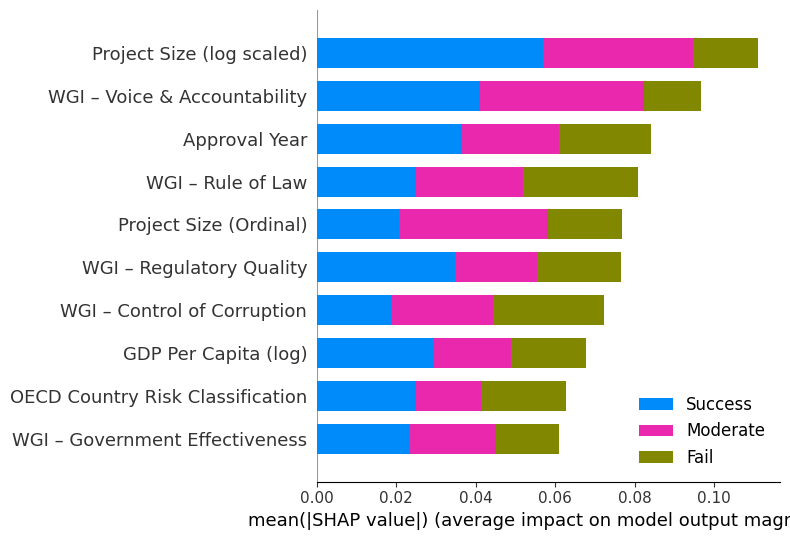


=== SHAP Beeswarm for Class: Fail ===


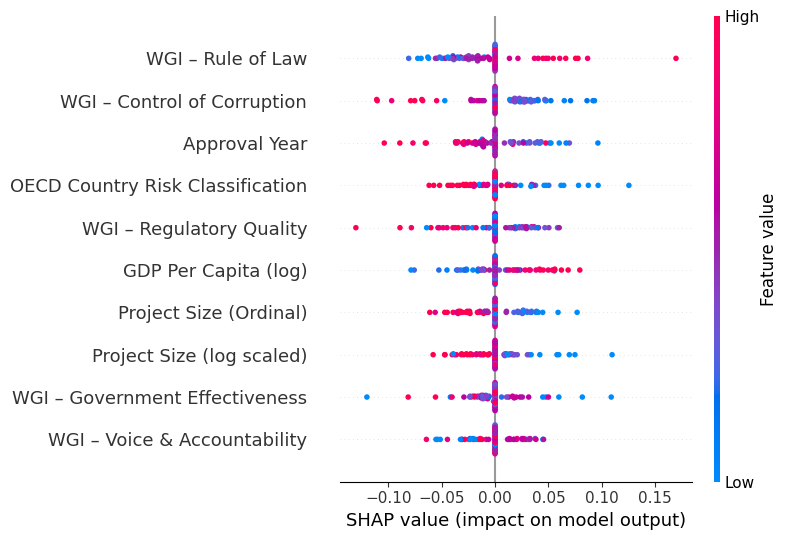


=== SHAP Beeswarm for Class: Moderate ===


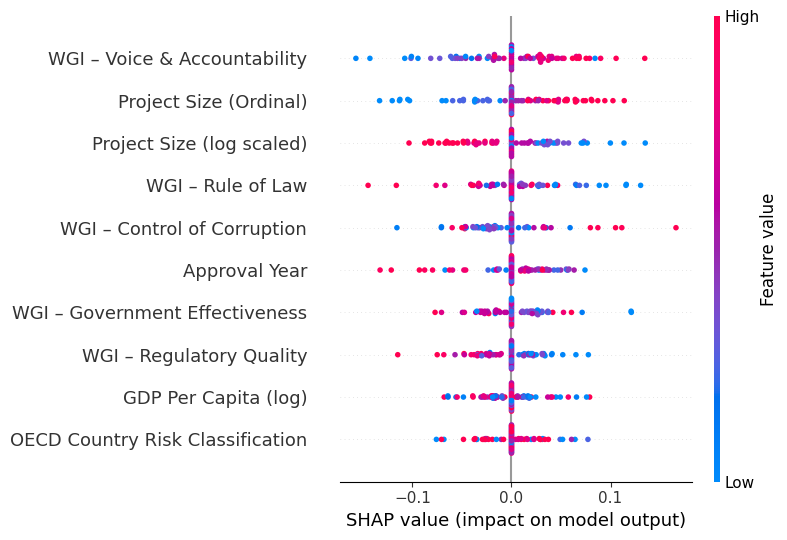


=== SHAP Beeswarm for Class: Success ===


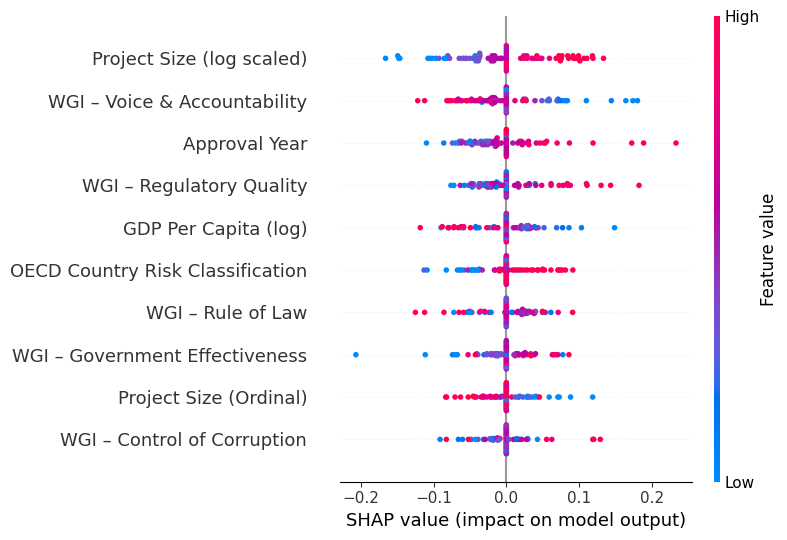

In [97]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier

# =========================================================
# 0) Feature Name Mapping (Readable labels)
# =========================================================
feature_long_names = {
    "wgi_cc": "WGI – Control of Corruption",
    "wgi_ge": "WGI – Government Effectiveness",
    "wgi_pv": "WGI – Political Stability",
    "wgi_rl": "WGI – Rule of Law",
    "wgi_rq": "WGI – Regulatory Quality",
    "wgi_va": "WGI – Voice & Accountability",
    "Approval FY": "Approval Year",
    "CRC_Risk": "OECD Country Risk Classification",
    "log_project_volume": "Project Size (log scaled)",
    "Project_Volume_Ordinal": "Project Size (Ordinal)",
    "log_gdp_pc": "GDP Per Capita (log)",
    "log_gdp_growth": "GDP Growth (log)",
    "log_inflation": "Inflation (log)",
}

# 전처리 후 feature names 추출
feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
)

# 사람이 읽기 좋게 변환
feature_names_readable = [feature_long_names.get(f, f) for f in feature_names]


# =========================================================
# 1) Calibrated MLP 구성 및 학습
# =========================================================
mlp_base = MLPClassifier(
    hidden_layer_sizes=(40, 200),
    activation="relu",
    solver="adam",
    learning_rate_init=0.0012644763,
    alpha=0.0017022309,
    batch_size=256,
    max_iter=500,
    random_state=42
)

mlp_calibrated = CalibratedClassifierCV(mlp_base, method="isotonic", cv=3)

mlp_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", mlp_calibrated)
])

mlp_pipe.fit(X_train, y_train)


# =========================================================
# 2) SHAP sample 준비
# =========================================================
X_test_trans = mlp_pipe.named_steps["preprocessor"].transform(X_test)

n_samples = min(80, X_test_trans.shape[0])
idx = np.random.choice(X_test_trans.shape[0], n_samples, replace=False)
X_sample = X_test_trans[idx]

background = X_sample[:30]   # SHAP background


# =========================================================
# 3) SHAP per class 계산
# =========================================================
shap_values_per_class = []

for c in range(3):
    print(f"\n[SHAP] Computing class {c} (Fail=0, Moderate=1, Success=2)...")

    f = lambda x: mlp_pipe.named_steps["model"].predict_proba(x)[:, c]

    explainer_c = shap.KernelExplainer(f, background)
    sv = explainer_c.shap_values(X_sample)     # shape: (n_samples, n_features)

    shap_values_per_class.append(sv)


# =========================================================
# 4) Top 10 feature 선택
# =========================================================
mean_shap = np.mean(
    np.abs(shap_values_per_class[0]) +
    np.abs(shap_values_per_class[1]) +
    np.abs(shap_values_per_class[2]),
    axis=0
)

top_k = 10
top_idx = np.argsort(mean_shap)[-top_k:]
top_idx_sorted = np.sort(top_idx)

feature_names_top = np.array(feature_names_readable)[top_idx_sorted]

X_sample_shap = X_sample[:, top_idx_sorted]

shap_values_top = [
    sv[:, top_idx_sorted] for sv in shap_values_per_class
]

assert X_sample_shap.shape[1] == shap_values_top[0].shape[1]


# =========================================================
# 5) SHAP Summary Bar Plot (Global)
# =========================================================
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values_top,
    X_sample_shap,
    feature_names=feature_names_top,
    class_names=["Fail","Moderate","Success"],
    plot_type="bar",
    max_display=10
)


# =========================================================
# 6) Class-wise Beeswarm Plots
# =========================================================
for i, cname in enumerate(["Fail","Moderate","Success"]):
    print(f"\n=== SHAP Beeswarm for Class: {cname} ===")

    shap.summary_plot(
        shap_values_top[i],
        X_sample_shap,
        feature_names=feature_names_top,
        max_display=10
    )

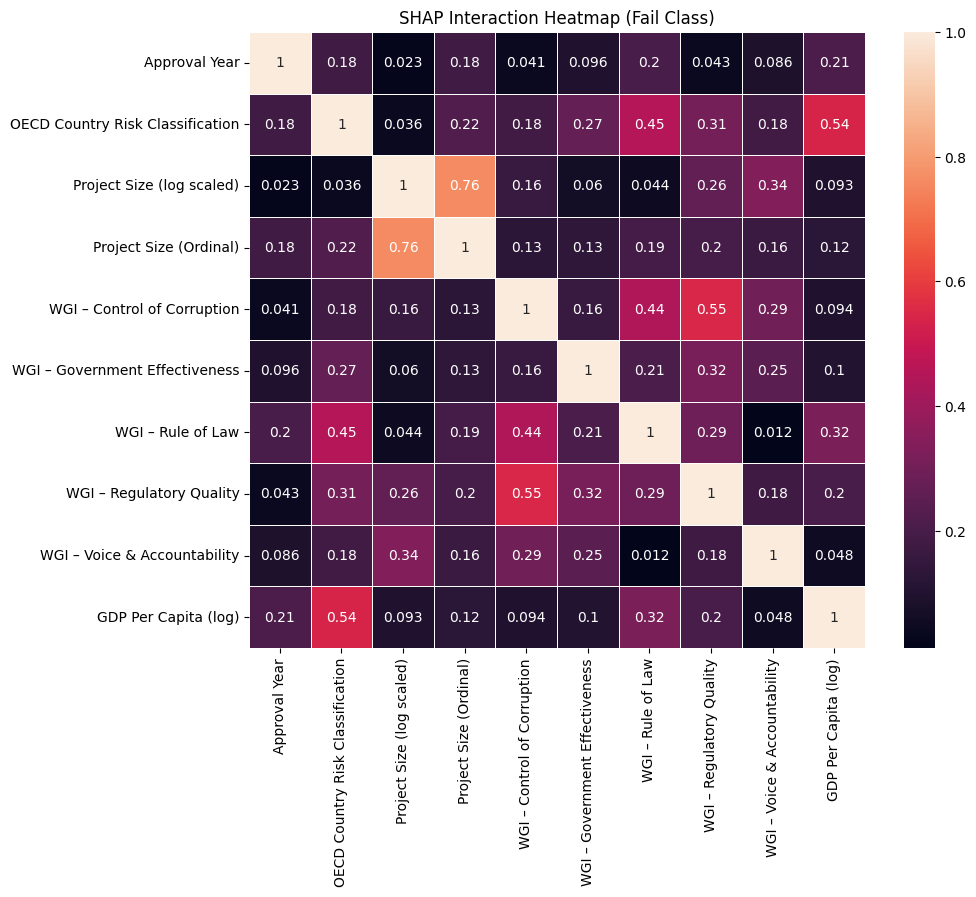

In [98]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===========================
# 1. Fail 클래스 SHAP 값 사용
# ===========================
class_idx = 0   # Fail class

shap_matrix = shap_values_top[class_idx]   # (n_samples, 10)
X_matrix = X_sample_shap                   # (n_samples, 10)
feat_names = feature_names_top             # 이름 10개


# ===========================
# 2. Interaction strength 계산
#    |corr(SHAP_i, SHAP_j)| 로 근사
# ===========================
interaction_mat = np.zeros((len(feat_names), len(feat_names)))

for i in range(len(feat_names)):
    for j in range(len(feat_names)):
        interaction_mat[i, j] = np.abs(
            np.corrcoef(shap_matrix[:, i], shap_matrix[:, j])[0, 1]
        )


# ===========================
# 3. Panda dataframe 변환
# ===========================
interaction_df = pd.DataFrame(
    interaction_mat,
    index=feat_names,
    columns=feat_names
)


# ===========================
# 4. Heatmap 그리기
# ===========================
plt.figure(figsize=(10, 8))
sns.heatmap(
    interaction_df,
    annot=True,
    linewidths=.5,
    square=True
)
plt.title("SHAP Interaction Heatmap (Fail Class)")
plt.show()

In [100]:
# ---------------------------------------------------
# 준비된 값 (너 이미 계산함)
# shap_values_top     : [class0, class1, class2] 형태 SHAP 리스트
# feature_names_top   : Top10 readable feature names
# X_sample_shap       : SHAP과 같은 샘플 X
# ---------------------------------------------------

# 🔥 Fail 클래스(0번 클래스) SHAP 값
shap_fail = shap_values_top[0]      # shape: (N_samples, N_features)

# 🔍 Rule of Law index 찾기
try:
    rol_idx = feature_names_top.tolist().index("WGI – Rule of Law")
except:
    raise ValueError("Rule of Law feature not found in feature_names_top")


# =====================================================
# 1) ROL × ALL FEATURES — Interaction SHAP 계산
# =====================================================
interaction_scores = {}

for i, fname in enumerate(feature_names_top):

    if i == rol_idx:
        continue   # 자기 자신 제외

    # Interaction strength = 평균(|SHAP_rol + SHAP_i|)
    interaction_strength = np.mean(
        np.abs(shap_fail[:, rol_idx] + shap_fail[:, i])
    )

    interaction_scores[fname] = interaction_strength


# DataFrame으로 정리
interaction_df = (
    pd.DataFrame.from_dict(interaction_scores, orient="index", columns=["Interaction"])
      .sort_values("Interaction", ascending=False)
)

print("\n=== ROL × ALL FEATURES Interaction Ranking ===")
display(interaction_df)



=== ROL × ALL FEATURES Interaction Ranking ===


,Interaction
Approval Year,0.046013
OECD Country Risk Classification,0.045116
GDP Per Capita (log),0.043090
Project Size (Ordinal),0.040344
Project Size (log scaled),0.039147
WGI – Voice & Accountability,0.036878
WGI – Regulatory Quality,0.034455
WGI – Government Effectiveness,0.033875
WGI – Control of Corruption,0.032623


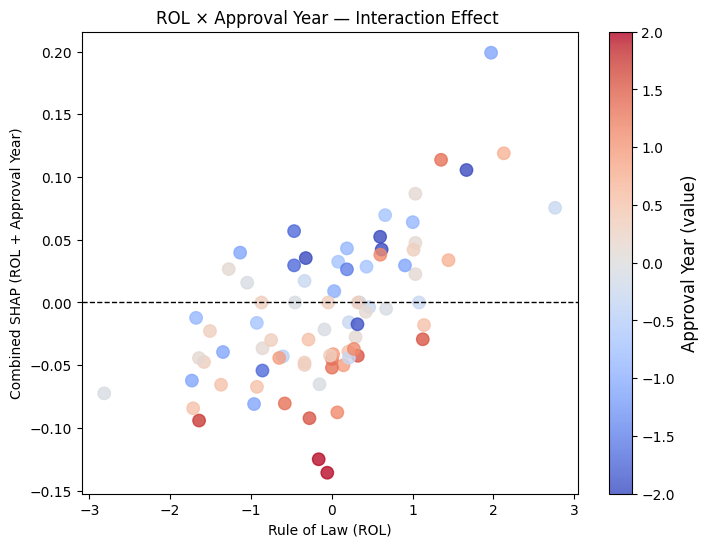

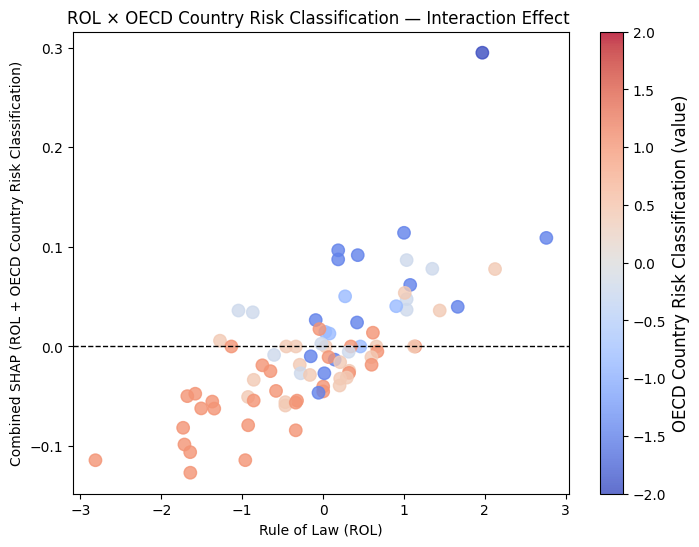

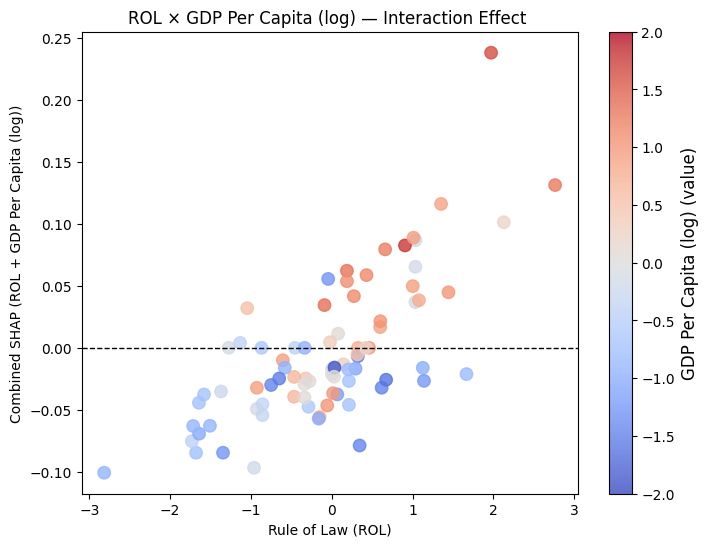

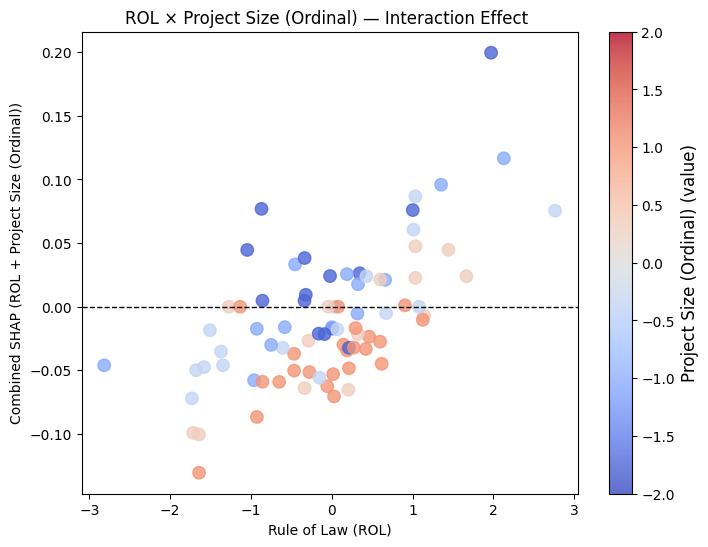

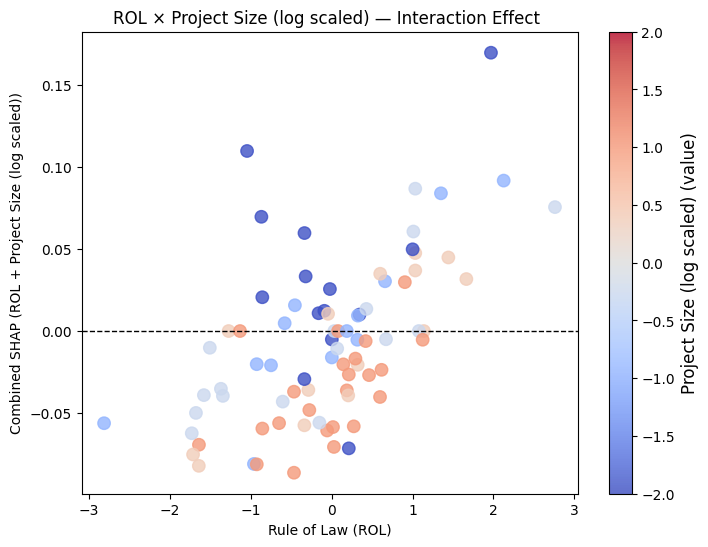

In [102]:

# =====================================================
# 3) 색상 범위를 -2 ~ +2로 고정한 상호작용 플롯 함수
# =====================================================
def plot_interaction(feature_name):

    i = feature_names_top.tolist().index(feature_name)
    combined_shap = shap_fail[:, rol_idx] + shap_fail[:, i]

    plt.figure(figsize=(8,6))
    plt.scatter(
        X_sample_shap[:, rol_idx],
        combined_shap,
        c=X_sample_shap[:, i],
        cmap="coolwarm",
        vmin=-2, vmax=2,      # 🔥 색상 고정
        s=80,
        alpha=0.8
    )

    plt.axhline(0, color="black", linestyle="--", linewidth=1)

    plt.xlabel("Rule of Law (ROL)")
    plt.ylabel(f"Combined SHAP (ROL + {feature_name})")
    plt.title(f"ROL × {feature_name} — Interaction Effect ")

    cbar = plt.colorbar()
    cbar.set_label(f"{feature_name} (value)", fontsize=12)

    plt.show()


# =====================================================
# 4) 상위 5개 feature 자동 플로팅
# =====================================================
top5_features = interaction_df.index[:5]

for fname in top5_features:
    plot_interaction(fname)

In [103]:
def warn_for_single_project(project_row, model_pipe, feature_names_readable, top_k=5):
    """
    project_row: 1-row DataFrame (raw features)
    model_pipe: trained MLP pipeline
    feature_names_readable: readable names aligned to transformed features
    """

    # -------------------------------
    # 1) Prediction
    # -------------------------------
    probs = model_pipe.predict_proba(project_row)[0]
    fail_p, mod_p, succ_p = probs

    print("==== Prediction ====")
    print(f"Fail Probability:      {fail_p:.3f}")
    print(f"Moderate Probability:  {mod_p:.3f}")
    print(f"Success Probability:   {succ_p:.3f}\n")

    # -------------------------------
    # 2) Preprocess the sample
    # -------------------------------
    X_proc = model_pipe.named_steps["preprocessor"].transform(project_row)

    # background: random 50 samples from training set (안정성 ↑)
    bg_idx = np.random.choice(len(X_train), size=min(50, len(X_train)), replace=False)
    background = model_pipe.named_steps["preprocessor"].transform(X_train.iloc[bg_idx])

    # -------------------------------
    # 3) SHAP for FAIL Class (class 0)
    # -------------------------------
    f_fail = lambda x: model_pipe.named_steps["model"].predict_proba(x)[:, 0]

    explainer = shap.KernelExplainer(f_fail, background)
    shap_values = explainer.shap_values(X_proc)[0]     # shape = (n_features,)

    # -------------------------------
    # 4) SHAP Ranking
    # -------------------------------
    shap_abs = np.abs(shap_values)
    top_idx = np.argsort(shap_abs)[-top_k:][::-1]


    print("==== Top Contributing Factors (Fail Risk) ====")
    for idx in top_idx:
        fname = feature_names_readable[idx]
        sval = shap_values[idx]
        effect = "⬆ Fail risk" if sval > 0 else "⬇ Fail risk"
        print(f"{fname:40s} | SHAP = {sval:+.4f} | {effect}")

    # -------------------------------
    # 5) HUMAN-FRIENDLY RISK WARNING
    # -------------------------------
    print("\n==== Risk Warning ====")
    if fail_p > 0.7:
        print("⚠ 프로젝트는 **실패 확률이 매우 높습니다**. 다음 요인을 우선적으로 점검해야 합니다:")
    elif fail_p > 0.4:
        print("⚠ 프로젝트는 **중간 수준의 실패 리스크**가 존재합니다. 아래 요인을 확인하세요:")
    else:
        print("✓ 실패 리스크는 낮지만, 아래 요인은 계속 모니터링해야 합니다:")

    for idx in top_idx:
        fname = feature_names_readable[idx]
        sval = shap_values[idx]

        if sval > 0:
            print(f"  • {fname}: 실패 가능성을 증가시키는 요인 (↑)")
        else:
            print(f"  • {fname}: 성공 방향으로 작용하지만 모델이 민감하게 반응하는 요인 (↓)")

In [104]:
single_project = df.iloc[[4503]][features]
warn_for_single_project(single_project, mlp_pipe, feature_names_readable)

==== Prediction ====
Fail Probability:      0.690
Moderate Probability:  0.200
Success Probability:   0.111



  0%|          | 0/1 [00:00<?, ?it/s]

==== Top Contributing Factors (Fail Risk) ====
WGI – Control of Corruption              | SHAP = +0.1661 | ⬆ Fail risk
WGI – Government Effectiveness           | SHAP = +0.1373 | ⬆ Fail risk
WGI – Political Stability                | SHAP = +0.0693 | ⬆ Fail risk
WGI – Regulatory Quality                 | SHAP = -0.0467 | ⬇ Fail risk
WGI – Voice & Accountability             | SHAP = +0.0362 | ⬆ Fail risk

==== Risk Warning ====
⚠ 프로젝트는 **중간 수준의 실패 리스크**가 존재합니다. 아래 요인을 확인하세요:
  • WGI – Control of Corruption: 실패 가능성을 증가시키는 요인 (↑)
  • WGI – Government Effectiveness: 실패 가능성을 증가시키는 요인 (↑)
  • WGI – Political Stability: 실패 가능성을 증가시키는 요인 (↑)
  • WGI – Regulatory Quality: 성공 방향으로 작용하지만 모델이 민감하게 반응하는 요인 (↓)
  • WGI – Voice & Accountability: 실패 가능성을 증가시키는 요인 (↑)
